In [79]:
# Import required libraries and define the project data path

from pathlib import Path
import polars as pl

In [80]:
PROJECT_ROOT = Path.cwd().parents[1]
DATA_ROOT = PROJECT_ROOT / "tennis_data"
data_path = DATA_ROOT / "Data"

In [81]:
# Load event and score datasets required for Question 12

event = pl.read_parquet(data_path / "event.parquet")
home_score = pl.read_parquet(data_path / "home_team_score.parquet")
away_score = pl.read_parquet(data_path / "away_team_score.parquet")

In [82]:
# Check the number of snapshots available for each match in the score datasets

home_score.group_by("match_id").len().select(
    pl.col("len").value_counts()
).unnest("len")

len,count
u32,u32
1,896
4,13
2,13676
3,2288


In [83]:
# Count the number of non-null set scores in each home score snapshot

home_score_check = home_score.with_columns(
    pl.sum_horizontal(
        [
            pl.col("period_1").is_not_null().cast(pl.Int8),
            pl.col("period_2").is_not_null().cast(pl.Int8),
            pl.col("period_3").is_not_null().cast(pl.Int8),
            pl.col("period_4").is_not_null().cast(pl.Int8),
            pl.col("period_5").is_not_null().cast(pl.Int8),
        ]
    ).alias("available_sets")
)

home_score_check.select(
    ["match_id", "snapshot_date", "available_sets"]
).filter(
    pl.col("available_sets") > 0
).head(20)

match_id,snapshot_date,available_sets
i64,date,i8
11998445,2024-02-01,3
11998445,2024-02-02,3
11998446,2024-02-01,2
11998446,2024-02-02,2
11998447,2024-02-01,2
…,…,…
11998454,2024-02-03,2
11998455,2024-02-04,3
11998455,2024-02-05,3


In [84]:
# Check whether the number of available sets changes across snapshots of the same match

set_changes = (
    home_score_check
    .group_by("match_id")
    .agg(
        pl.col("available_sets").n_unique().alias("unique_set_counts")
    )
    .filter(
        pl.col("unique_set_counts") > 1
    )
)

print("Matches with changing available sets:", set_changes.height)

Matches with changing available sets: 1716


In [85]:
# Check whether the latest snapshot contains the maximum number of available sets for each match

snapshot_check = (
    home_score_check
    .sort(["match_id", "snapshot_date"])
    .group_by("match_id")
    .agg([
        pl.col("available_sets").last().alias("latest_sets"),
        pl.col("available_sets").max().alias("max_sets")
    ])
    .filter(
        pl.col("latest_sets") < pl.col("max_sets")
    )
)

print(
    "Matches where latest snapshot has fewer sets than an earlier snapshot:",
    snapshot_check.height
)

Matches where latest snapshot has fewer sets than an earlier snapshot: 0


In [86]:
# Check whether the latest away-score snapshot contains the maximum number of available sets

away_score_check = away_score.with_columns(
    pl.sum_horizontal(
        [
            pl.col("period_1").is_not_null().cast(pl.Int8),
            pl.col("period_2").is_not_null().cast(pl.Int8),
            pl.col("period_3").is_not_null().cast(pl.Int8),
            pl.col("period_4").is_not_null().cast(pl.Int8),
            pl.col("period_5").is_not_null().cast(pl.Int8),
        ]
    ).alias("available_sets")
)

away_snapshot_check = (
    away_score_check
    .sort(["match_id", "snapshot_date"])
    .group_by("match_id")
    .agg([
        pl.col("available_sets").last().alias("latest_sets"),
        pl.col("available_sets").max().alias("max_sets")
    ])
    .filter(
        pl.col("latest_sets") < pl.col("max_sets")
    )
)

print(
    "Matches where latest away snapshot has fewer sets than an earlier snapshot:",
    away_snapshot_check.height
)

Matches where latest away snapshot has fewer sets than an earlier snapshot: 0


In [87]:
# Keep only the latest score snapshot for each match

home_final = (
    home_score
    .sort(["match_id", "snapshot_date"])
    .unique(subset="match_id", keep="last")
)

away_final = (
    away_score
    .sort(["match_id", "snapshot_date"])
    .unique(subset="match_id", keep="last")
)

print("Home final matches:", home_final.height)
print("Away final matches:", away_final.height)

Home final matches: 16873
Away final matches: 16873


In [88]:
# Check whether Home and Away contain exactly the same match IDs

home_ids = set(home_final["match_id"].to_list())
away_ids = set(away_final["match_id"].to_list())

print("Only in Home:", len(home_ids - away_ids))
print("Only in Away:", len(away_ids - home_ids))
print("Same match IDs:", home_ids == away_ids)

Only in Home: 0
Only in Away: 0
Same match IDs: True


In [89]:
# Join the final Home and Away score snapshots for each match

scores = home_final.join(
    away_final,
    on="match_id",
    how="inner",
    suffix="_away"
)

print("Joined matches:", scores.height)
print("Number of columns:", scores.width)

Joined matches: 16873
Number of columns: 29


In [90]:
# Display all period columns after joining Home and Away scores

[column for column in scores.columns if "period_" in column]

['period_1',
 'period_2',
 'period_3',
 'period_4',
 'period_5',
 'period_1_tie_break',
 'period_2_tie_break',
 'period_3_tie_break',
 'period_4_tie_break',
 'period_5_tie_break',
 'period_1_away',
 'period_2_away',
 'period_3_away',
 'period_4_away',
 'period_5_away',
 'period_1_tie_break_away',
 'period_2_tie_break_away',
 'period_3_tie_break_away',
 'period_4_tie_break_away',
 'period_5_tie_break_away']

In [91]:
# Calculate the total number of games played in each set

scores_with_games = scores.with_columns([
    (pl.col("period_1") + pl.col("period_1_away")).alias("games_set_1"),
    (pl.col("period_2") + pl.col("period_2_away")).alias("games_set_2"),
    (pl.col("period_3") + pl.col("period_3_away")).alias("games_set_3"),
    (pl.col("period_4") + pl.col("period_4_away")).alias("games_set_4"),
    (pl.col("period_5") + pl.col("period_5_away")).alias("games_set_5"),
])

scores_with_games.select([
    "match_id",
    "period_1",
    "period_1_away",
    "games_set_1",
    "period_2",
    "period_2_away",
    "games_set_2"
]).head(20)

match_id,period_1,period_1_away,games_set_1,period_2,period_2_away,games_set_2
i64,i64,i64,i64,i64,i64,i64
11974049,null,null,null,null,null,null
11974052,null,null,null,null,null,null
11974053,null,null,null,null,null,null
11974065,null,null,null,null,null,null
11974066,null,null,null,null,null,null
…,…,…,…,…,…,…
11998448,6,4,10,6,4,10
11998449,1,6,7,4,6,10
11998450,6,1,7,6,7,13


In [92]:
# Check how many matches have at least one completed set in the final snapshot

set_columns = [
    "games_set_1",
    "games_set_2",
    "games_set_3",
    "games_set_4",
    "games_set_5"
]

matches_with_sets = scores_with_games.filter(
    pl.any_horizontal(
        [pl.col(column).is_not_null() for column in set_columns]
    )
)

print("Total matches:", scores_with_games.height)
print("Matches with set data:", matches_with_sets.height)
print(
    "Matches without set data:",
    scores_with_games.height - matches_with_sets.height
)

Total matches: 16873
Matches with set data: 16192
Matches without set data: 681


In [93]:
# Count the number of available sets for each match

matches_with_sets = matches_with_sets.with_columns(
    pl.sum_horizontal(
        [pl.col(column).is_not_null().cast(pl.Int8) for column in set_columns]
    ).alias("number_of_sets")
)

matches_with_sets.group_by("number_of_sets").len().sort("number_of_sets")

number_of_sets,len
i8,u32
1,120
2,11622
3,4450


In [94]:
# Load Home Team data for gender information

home_team = pl.read_parquet(data_path / "home_team.parquet")

print("Home Team rows:", home_team.height)
print("Home Team columns:", home_team.width)

Home Team rows: 25610
Home Team columns: 19


In [95]:
# Select the latest Home Team snapshot for each match and keep its gender

home_gender = (
    home_team
    .sort(["match_id", "snapshot_date"])
    .unique(subset="match_id", keep="last")
    .select(["match_id", "gender"])
    .rename({"gender": "home_gender"})
)

home_gender.head(10)

match_id,home_gender
i64,str
11998445,"""M"""
11998446,"""M"""
11998447,"""M"""
11998448,"""M"""
11998449,"""M"""
11998450,"""M"""
11998451,"""M"""
11998452,"""M"""
11998453,"""M"""


In [96]:
# Check all unique gender values in the Home Team data

home_gender.group_by("home_gender").len().sort("home_gender")

home_gender,len
str,u32
null,19
"""F""",5254
"""M""",7116


In [97]:
# Load Away Team data for gender information

away_team = pl.read_parquet(data_path / "away_team.parquet")

print("Away Team rows:", away_team.height)
print("Away Team columns:", away_team.width)

Away Team rows: 24203
Away Team columns: 19


In [98]:
# Select the latest Away Team snapshot for each match and keep its gender

away_gender = (
    away_team
    .sort(["match_id", "snapshot_date"])
    .unique(subset="match_id", keep="last")
    .select(["match_id", "gender"])
    .rename({"gender": "away_gender"})
)

away_gender.head(10)

match_id,away_gender
i64,str
11998445,"""M"""
11998446,"""M"""
11998447,"""M"""
11998448,"""M"""
11998449,"""M"""
11998450,"""M"""
11998451,"""M"""
11998452,"""M"""
11998453,"""M"""


In [99]:
# Join Home and Away gender information with match scores

scores_gender = (
    scores_with_games
    .join(home_gender, on="match_id", how="left")
    .join(away_gender, on="match_id", how="left")
)

scores_gender.select(
    ["match_id", "home_gender", "away_gender"]
).head(20)

match_id,home_gender,away_gender
i64,str,str
11974049,null,null
11974052,null,null
11974053,null,null
11974065,null,null
11974066,null,null
…,…,…
11998448,"""M""","""M"""
11998449,"""M""","""M"""
11998450,"""M""","""M"""


In [100]:
# Check gender consistency between Home and Away players

gender_check = (
    scores_gender
    .filter(
        pl.col("home_gender").is_not_null() &
        pl.col("away_gender").is_not_null()
    )
    .group_by(["home_gender", "away_gender"])
    .len()
    .sort("len", descending=True)
)

gender_check

home_gender,away_gender,len
str,str,u32
"""M""","""M""",5545
"""F""","""F""",4313


In [101]:
# Create one gender column for each match

scores_gender = scores_gender.with_columns(
    pl.coalesce(
        ["home_gender", "away_gender"]
    ).alias("gender")
)

scores_gender.group_by("gender").len().sort("len", descending=True)

gender,len
str,u32
"""M""",8228
"""F""",5958
null,2687


In [102]:
# Check usable matches by gender

usable_matches = (
    scores_gender
    .filter(
        pl.col("gender").is_not_null() &
        pl.col("games_set_1").is_not_null()
    )
)

usable_matches.group_by("gender").len().sort("gender")

gender,len
str,u32
"""F""",5784
"""M""",7919


In [103]:
# Convert set columns into rows

sets_long = (
    usable_matches
    .unpivot(
        on=[
            "games_set_1",
            "games_set_2",
            "games_set_3",
            "games_set_4",
            "games_set_5"
        ],
        index=["match_id", "gender"],
        variable_name="set",
        value_name="games"
    )
    .filter(pl.col("games").is_not_null())
)

sets_long.head(20)

match_id,gender,set,games
i64,str,str,i64
11998445,"""M""","""games_set_1""",12
11998446,"""M""","""games_set_1""",10
11998447,"""M""","""games_set_1""",10
11998448,"""M""","""games_set_1""",10
11998449,"""M""","""games_set_1""",7
…,…,…,…
11998663,"""M""","""games_set_1""",8
11998664,"""M""","""games_set_1""",13
11998666,"""M""","""games_set_1""",10


In [104]:
# Check the distribution and range of games per set

sets_long.select(
    pl.col("games").min().alias("min_games"),
    pl.col("games").max().alias("max_games"),
    pl.col("games").mean().alias("mean_games"),
    pl.col("games").median().alias("median_games")
)

min_games,max_games,mean_games,median_games
i64,i64,f64,f64
0,40,9.426724,9.0


In [105]:
# Check zero values in each set

sets_long.group_by("set").agg(
    pl.len().alias("total_rows"),
    (pl.col("games") == 0).sum().alias("zero_games"),
    (pl.col("games") > 0).sum().alias("positive_games")
).sort("set")

set,total_rows,zero_games,positive_games
str,u32,u32,u32
"""games_set_1""",13703,3,13700
"""games_set_2""",13590,17,13573
"""games_set_3""",3877,3,3874


In [106]:
# Recheck games statistics after removing zero values

valid_sets = sets_long.filter(
    pl.col("games") > 0
)

valid_sets.select(
    pl.len().alias("total_sets"),
    pl.col("games").min().alias("min_games"),
    pl.col("games").max().alias("max_games"),
    pl.col("games").mean().alias("mean_games"),
    pl.col("games").median().alias("median_games")
)

total_sets,min_games,max_games,mean_games,median_games
u32,i64,i64,f64,f64
31147,1,40,9.433685,9.0


In [107]:
# Check unusual game counts

valid_sets.group_by("games").len().sort("games")

games,len
i64,u32
1,43
2,45
3,60
4,42
5,67
…,…
29,2
30,2
31,1


In [108]:
# Check unusual sets by gender and set number

unusual_sets = (
    valid_sets
    .filter(
        (pl.col("games") < 6) |
        (pl.col("games") > 13)
    )
    .group_by(["gender", "set"])
    .agg(
        pl.len().alias("count"),
        pl.col("games").min().alias("min_games"),
        pl.col("games").max().alias("max_games")
    )
    .sort(["gender", "set"])
)

unusual_sets

gender,set,count,min_games,max_games
str,str,u32,i64,i64
"""F""","""games_set_1""",60,1,15
"""F""","""games_set_2""",102,1,15
"""F""","""games_set_3""",345,1,31
"""M""","""games_set_1""",92,1,15
"""M""","""games_set_2""",150,1,15
"""M""","""games_set_3""",581,1,40


In [109]:
# Inspect sets with very high number of games

high_games = (
    sets_long
    .filter(pl.col("games") > 15)
    .sort("games", descending=True)
)

high_games

match_id,gender,set,games
i64,str,str,i64
12041957,"""M""","""games_set_3""",40
12078777,"""M""","""games_set_3""",32
12121259,"""F""","""games_set_3""",31
12042582,"""M""","""games_set_3""",30
12123966,"""M""","""games_set_3""",30
…,…,…,…
12209654,"""M""","""games_set_3""",16
12209811,"""M""","""games_set_3""",16
12211784,"""M""","""games_set_3""",16


In [110]:
# Check distribution of high-game sets by gender and set number

high_games_summary = (
    high_games
    .group_by(["gender", "set"])
    .agg(
        pl.len().alias("count"),
        pl.col("games").min().alias("min_games"),
        pl.col("games").max().alias("max_games"),
        pl.col("games").mean().alias("mean_games")
    )
    .sort(["gender", "set"])
)

high_games_summary

gender,set,count,min_games,max_games,mean_games
str,str,u32,i64,i64,f64
"""F""","""games_set_3""",244,16,31,18.467213
"""M""","""games_set_3""",402,16,40,18.340796


In [111]:
# Calculate average games per set by gender

avg_games_by_gender_set = (
    sets_long
    .filter(pl.col("games") > 0)
    .group_by(["gender", "set"])
    .agg(
        pl.len().alias("number_of_sets"),
        pl.col("games").mean().alias("avg_games"),
        pl.col("games").median().alias("median_games")
    )
    .sort(["set", "gender"])
)

avg_games_by_gender_set

gender,set,number_of_sets,avg_games,median_games
str,str,u32,f64,f64
"""F""","""games_set_1""",5782,9.052577,9.0
"""M""","""games_set_1""",7918,9.423087,9.0
"""F""","""games_set_2""",5727,8.925965,9.0
"""M""","""games_set_2""",7846,9.239103,9.0
"""F""","""games_set_3""",1597,10.819036,10.0
"""M""","""games_set_3""",2277,11.414141,10.0


In [112]:
# Calculate average games per set by gender

avg_games_by_gender_set = (
    sets_long
    .filter(pl.col("games") > 0)
    .group_by(["gender", "set"])
    .agg(
        pl.len().alias("number_of_sets"),
        pl.col("games").mean().alias("avg_games"),
        pl.col("games").median().alias("median_games")
    )
    .sort(["set", "gender"])
)

avg_games_by_gender_set

gender,set,number_of_sets,avg_games,median_games
str,str,u32,f64,f64
"""F""","""games_set_1""",5782,9.052577,9.0
"""M""","""games_set_1""",7918,9.423087,9.0
"""F""","""games_set_2""",5727,8.925965,9.0
"""M""","""games_set_2""",7846,9.239103,9.0
"""F""","""games_set_3""",1597,10.819036,10.0
"""M""","""games_set_3""",2277,11.414141,10.0


In [113]:
# Calculate overall average games per set by gender

overall_avg_games = (
    sets_long
    .filter(pl.col("games") > 0)
    .group_by("gender")
    .agg(
        pl.len().alias("total_sets"),
        pl.col("games").mean().alias("avg_games_per_set"),
        pl.col("games").median().alias("median_games_per_set")
    )
    .sort("gender")
)

overall_avg_games

gender,total_sets,avg_games_per_set,median_games_per_set
str,u32,f64,f64
"""F""",13106,9.212498,9.0
"""M""",18041,9.594368,9.0


In [114]:
# Calculate the difference between male and female averages

female_avg = (
    sets_long
    .filter((pl.col("gender") == "F") & (pl.col("games") > 0))
    .select(pl.col("games").mean())
    .item()
)

male_avg = (
    sets_long
    .filter((pl.col("gender") == "M") & (pl.col("games") > 0))
    .select(pl.col("games").mean())
    .item()
)

difference = male_avg - female_avg
percentage_difference = (difference / female_avg) * 100

print("Female average:", round(female_avg, 3))
print("Male average:", round(male_avg, 3))
print("Difference:", round(difference, 3))
print("Percentage difference:", round(percentage_difference, 2), "%")

Female average: 9.212
Male average: 9.594
Difference: 0.382
Percentage difference: 4.15 %


In [115]:
# Create final comparison table

final_comparison = (
    avg_games_by_gender_set
    .select(["gender", "set", "avg_games"])
    .pivot(
        values="avg_games",
        index="set",
        on="gender"
    )
    .rename({
        "F": "female_avg",
        "M": "male_avg"
    })
    .with_columns(
        (pl.col("male_avg") - pl.col("female_avg"))
        .alias("difference")
    )
    .sort("set")
)

final_comparison

set,female_avg,male_avg,difference
str,f64,f64,f64
"""games_set_1""",9.052577,9.423087,0.37051
"""games_set_2""",8.925965,9.239103,0.313138
"""games_set_3""",10.819036,11.414141,0.595106


In [116]:
# Add overall averages to the final comparison table

overall_row = pl.DataFrame({
    "set": ["Overall"],
    "female_avg": [9.212498],
    "male_avg": [9.594368],
    "difference": [9.594368 - 9.212498]
})

final_result = pl.concat([
    final_comparison,
    overall_row
])

final_result

set,female_avg,male_avg,difference
str,f64,f64,f64
"""games_set_1""",9.052577,9.423087,0.37051
"""games_set_2""",8.925965,9.239103,0.313138
"""games_set_3""",10.819036,11.414141,0.595106
"""Overall""",9.212498,9.594368,0.38187


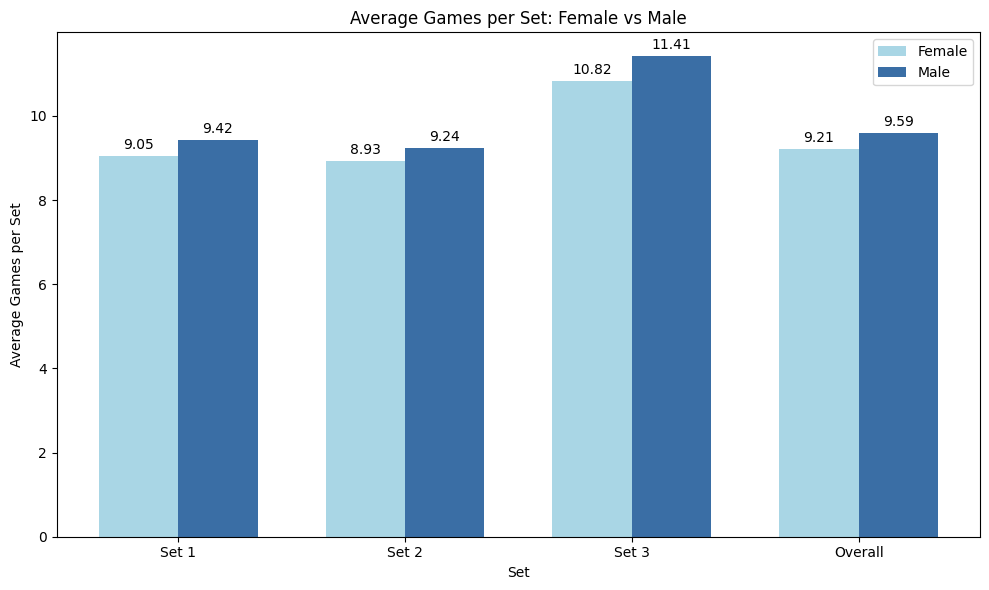

In [117]:
import matplotlib.pyplot as plt
import numpy as np

# Data from final_result
labels = ["Set 1", "Set 2", "Set 3", "Overall"]

female = final_result["female_avg"].to_list()
male = final_result["male_avg"].to_list()

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 6))

bars_f = plt.bar(x - width/2, female, width, label="Female", color= "#A9D6E5")
bars_m = plt.bar(x + width/2, male, width, label="Male", color= "#3A6EA5")

# Show values on bars
plt.bar_label(bars_f, fmt="%.2f", padding=3)
plt.bar_label(bars_m, fmt="%.2f", padding=3)

plt.xticks(x, labels)
plt.ylabel("Average Games per Set")
plt.xlabel("Set")
plt.title("Average Games per Set: Female vs Male")
plt.legend()

plt.tight_layout()
plt.show()